# 1. scikit learn의 LinearRgression  선형회귀 모델 구조 이해

 회귀선(fitted line) : hat_y = 0.53 * X + -32.50 
 R^2 : 0.92
 MSE : 0.73
 테스트 데이터 : 167cm의 추정 몸무게는 56.22kg입니다.   
 테스트 데이터 : 170cm의 추정 몸무게는 57.81kg입니다.   


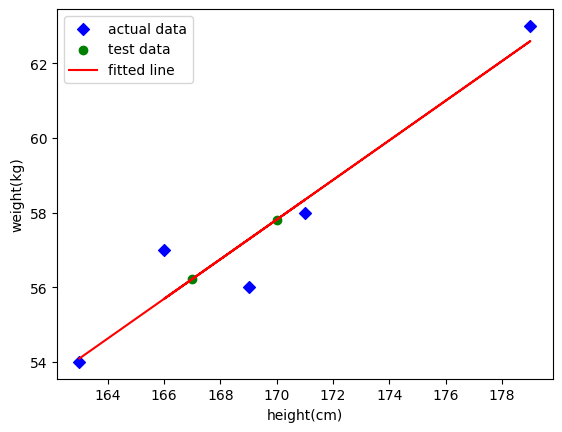

In [ ]:
# Ex1 : 키 정보을 이용해서 몸무게 예측하는 예측 모델 만들어서 테스트하기
import matplotlib.pyplot as plt
from sklearn import linear_model # 선형회귀 모델
from sklearn.metrics import mean_squared_error, r2_score # 성능평가

# 1. 지도학습 기반 데이터 준비
X = [[163],[179],[166],[169],[171]] # feature : 독립변수 - 키 - 2차원 배열
y = [54, 63, 57, 56, 58]  # target : 종속변수, label - 몸무게 - 1차원 배열

# 2. 모델 (가설) 설정 - 단순선형관계
regr = linear_model.LinearRegression()

# 3. 모델을 지도 학습시키기
regr.fit(X, y)

# 4. 학습된 모델의 파라미터 & 회귀선 찾기
coef = regr.coef_  # 기울기- 넘파이 이차원 배열
intercept = regr.intercept_  # 절편 - 실수값
print(f" 회귀선(fitted line) : hat_y = {coef[0]:.2f} * X + {intercept:.2f} ")

# 5. 학습된 모델의 성능 평가
# (1) R^2 (결정계수)
r2_score = r2_score(y, regr.predict(X))
print(f" R^2 : {r2_score:.2f}")

#(2) MSE(평균 제곱오차)
mse = mean_squared_error(y, regr.predict(X))
print(f" MSE : {mse:.2f}")

# 6. 새로운 데이터(2이상) 예측모델을 이용해서 몸무게 예측하기
new_data = [[167], [170]]  # 2차원 배열
hat_y = regr.predict(new_data)
for i in range(len(new_data)):
  print(f" 테스트 데이터 : {new_data[i][0]}cm의 추정 몸무게는 {hat_y[i]:.2f}kg입니다.   ")

# 7. 결과 시각화 : 실제 데이터 분포(산점도), 회귀선(선), 테스트 데이터(산점도)
plt.scatter(X, y, color = 'blue', marker = 'D', label = "actual data")
plt.scatter(new_data, hat_y, color = 'green', marker = 'o', label = "test data")
y_pred = regr.predict(X)
plt.plot(X, y_pred, color = 'red', label = "fitted line")
plt.xlabel("height(cm)")
plt.ylabel("weight(kg)")
plt.legend()
plt.show()

# 2. 선형회귀모델의 성능 평가지표
- MSE의 개념 이해
- MSE 직접 구현 및 시각화


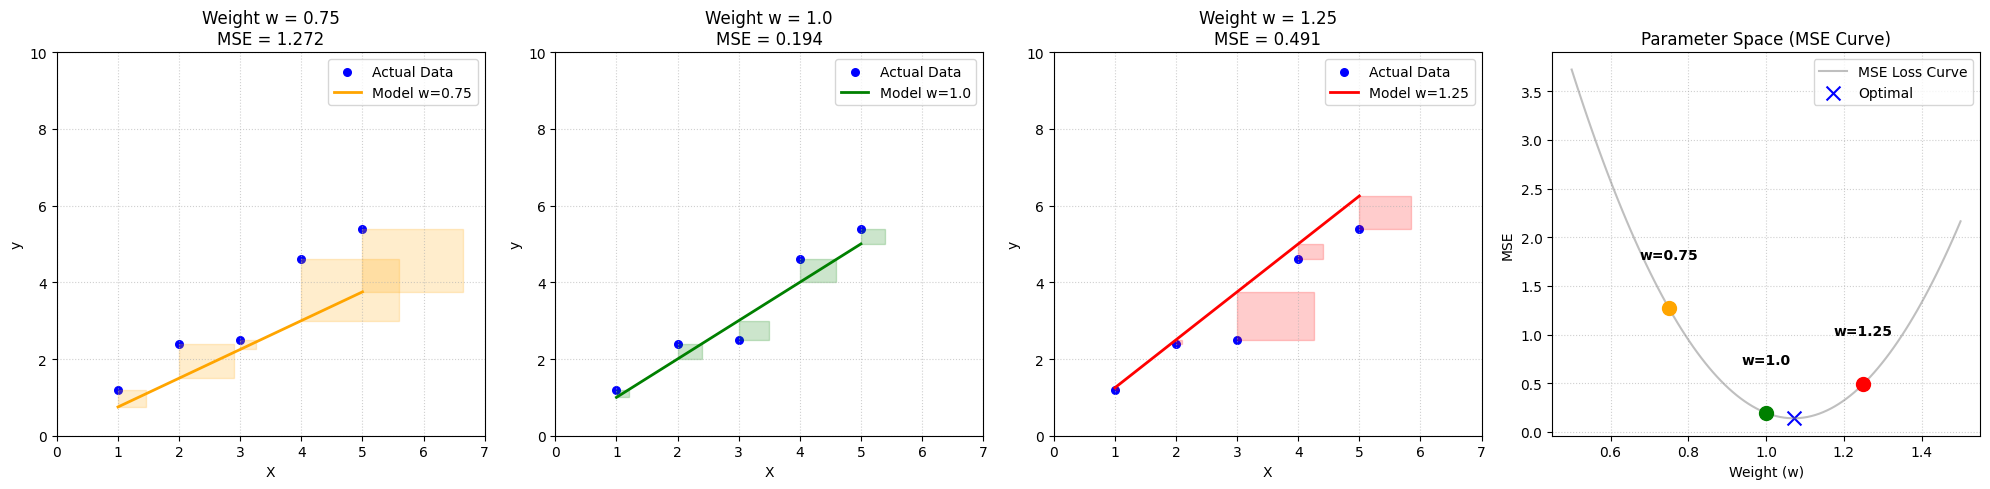

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 지도학습 데이터 설정
X = np.array([1, 2, 3, 4, 5])
y = np.array([1.2, 2.4, 2.5, 4.6, 5.4])

# 비교할 가중치(w) 값들
weights = [0.75, 1.0, 1.25]
colors = ['orange', 'green', 'red']

# 2. 전체 그림 크기 설정 (1행 4열 구조)
plt.figure(figsize=(20, 5))

# --- 가중치별 회귀 직선과 오차 사각형 시각화 (1~3번째 서브플롯) ---
for i, w in enumerate(weights):
    plt.subplot(1, 4, i + 1)

    # MSE 계산
    y_pred = w * X
    mse = np.mean((y - y_pred)**2)

    # 산점도 및 회귀 직선
    plt.scatter(X, y, color='blue', s=30, label='Actual Data')
    plt.plot(X, y_pred, color=colors[i], linewidth=2, label=f'Model w={w}')

    # 시각적 의미: 오차 사각형(Residual Squares) 그리기
    for xi, yi, ypi in zip(X, y, y_pred):
        err = abs(yi - ypi)
        # Rectangle 패치 추가 (왼쪽 하단 좌표, 너비, 높이)
        rect = plt.Rectangle((xi, min(yi, ypi)), err, err,
                             edgecolor=colors[i], facecolor=colors[i], alpha=0.2)
        plt.gca().add_patch(rect)

    plt.xlim(0, 7)
    plt.ylim(0, 10)
    plt.title(f'Weight w = {w}\nMSE = {mse:.3f}')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

# --- 3. 우측: MSE 곡선 (4번째 서브플롯) ---
plt.subplot(1, 4, 4)

# 곡선을 그리기 위한 가중치 후보군 (0.5부터 1.5까지 100개)
w_space = np.linspace(0.5, 1.5, 100)
mse_space = []

# 100개의 가중치 각각에 대한 MSE를 계산하여 리스트에 담기
for ws in w_space:
    current_predict = ws * X
    current_mse = np.mean((current_predict - y)**2) #MSE
    mse_space.append(current_mse)

# MSE 오차 곡선 함수 곡선 그리기
plt.plot(w_space, mse_space, color='gray', alpha=0.5, label='MSE Loss Curve')

# 처음에 설정한 3개의 가중치 위치를 점으로 표시
for w, color in zip(weights, colors):
    specific_mse = np.mean(((w * X) - y)**2) #MSE
    plt.scatter(w, specific_mse, color=color, s=100, zorder=5)
    plt.text(w, specific_mse + 0.5, f'w={w}', ha='center', fontweight='bold')

# 수학적으로 계산된 최적의 해(Optimal W) 표시 : X로 표시
optimal_w = np.sum(X * y) / np.sum(X**2)  #
optimal_mse = np.mean(((optimal_w * X) - y)**2) # MSE
plt.scatter(optimal_w, optimal_mse, color='blue', marker='x', s=100, label='Optimal')

plt.title('Parameter Space (MSE Curve)')
plt.xlabel('Weight (w)')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. 경사하강법
- 경사하강법알고리즘 이해
- 경사하강법 최적화 과정 시각화 (직선 & 오차 곡선)
- 경사하강법 알고리즘을 이용한 선형회귀선
- LinearRegression을 이용한 선형회귀 선

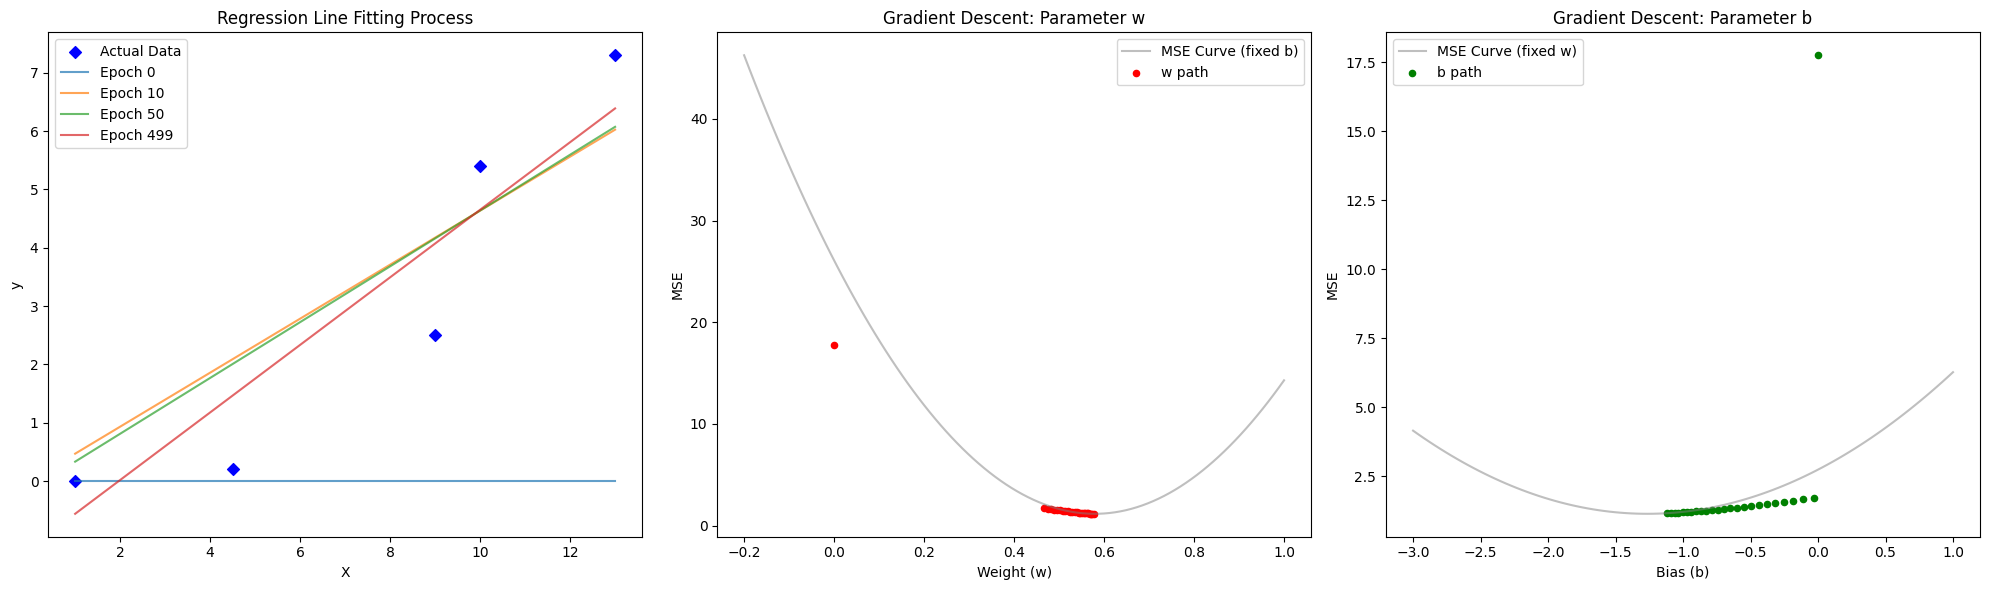

In [ ]:
# Ex1: 경사하강법 알고리즘 원리 이해
import numpy as np
import matplotlib.pyplot as plt

# 1. 지도학습 데이터 준비 : X 와 y가 상관관
X = np.array([1, 4.5, 9, 10, 13])
y = np.array([0, 0.2, 2.5, 5.4, 7.3])

# 2. 경사하강법 hyperparameter 설정
w = 0.0
b = 0.0
learning_rate = 0.005
epochs = 500

# 가중치, 절편 & mse 기록을 위한 리스트
w_history, b_history, mse_history = [], [], []

# 3. 학습 및 과정 기록
for i in range(epochs):
    y_pred = w * X + b
    error = y_pred - y

    # MSE 계산 및 기록
    mse = np.mean(error**2)
    w_history.append(w)
    b_history.append(b)
    mse_history.append(mse)

    # 파라미터 업데이트 (경사하강법)
    w = w - learning_rate * (error * X).mean() * 2
    b = b - learning_rate * error.mean() * 2

# 4. 시각화 (3개의 서브플롯)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: 데이터 공간 (회귀 직선의 변화) ---
ax1.scatter(X, y, color='blue', marker='D', label='Actual Data')
for idx in [0, 10, 50, epochs-1]:
    curr_w = w_history[idx]
    curr_b = b_history[idx]
    ax1.plot(X, curr_w * X + curr_b, label=f'Epoch {idx}', alpha=0.7)
ax1.set_title('Regression Line Fitting Process')
ax1.set_xlabel('X')
ax1.set_ylabel('y')
ax1.legend()

# --- Plot 2: Parameter w 공간에서의 MSE 곡선 ---
w_range = np.linspace(-0.2, 1.0, 100)
# b는 최종 최적값으로 고정하고 w 변화에 따른 MSE 계산
mse_range_w = [np.mean(((ws * X + b) - y)**2) for ws in w_range]
ax2.plot(w_range, mse_range_w, color='gray', alpha=0.5, label='MSE Curve (fixed b)')
ax2.scatter(w_history[::20], mse_history[::20], color='red', s=20, label='w path')
ax2.set_title('Gradient Descent: Parameter w')
ax2.set_xlabel('Weight (w)')
ax2.set_ylabel('MSE')
ax2.legend()

# --- Plot 3: Parameter b 공간에서의 MSE 곡선  ---
# b의 범위를 적절히 설정 (-3에서 1까지)
b_range = np.linspace(-3.0, 1.0, 100)
# w는 최종 최적값으로 고정하고 b 변화에 따른 MSE 계산
mse_range_b = [np.mean(((w * X + bs) - y)**2) for bs in b_range]
ax3.plot(b_range, mse_range_b, color='gray', alpha=0.5, label='MSE Curve (fixed w)')
ax3.scatter(b_history[::20], mse_history[::20], color='green', s=20, label='b path')
ax3.set_title('Gradient Descent: Parameter b')
ax3.set_xlabel('Bias (b)')
ax3.set_ylabel('MSE')
ax3.legend()

plt.tight_layout()
plt.show()

✅ 경사하강법에서 학습률(Learning Rate) 설정은 매우 중요한 문제
  - 학습률이 너무 높으면 최적의 지점을 지나쳐 반대편으로 튕겨 올라가는 '과도한 보폭' 현상이 발생하고,

  - 오차가 줄어들지 않고 기하급수적으로 커지는 '오차의 증폭' 현상 발생



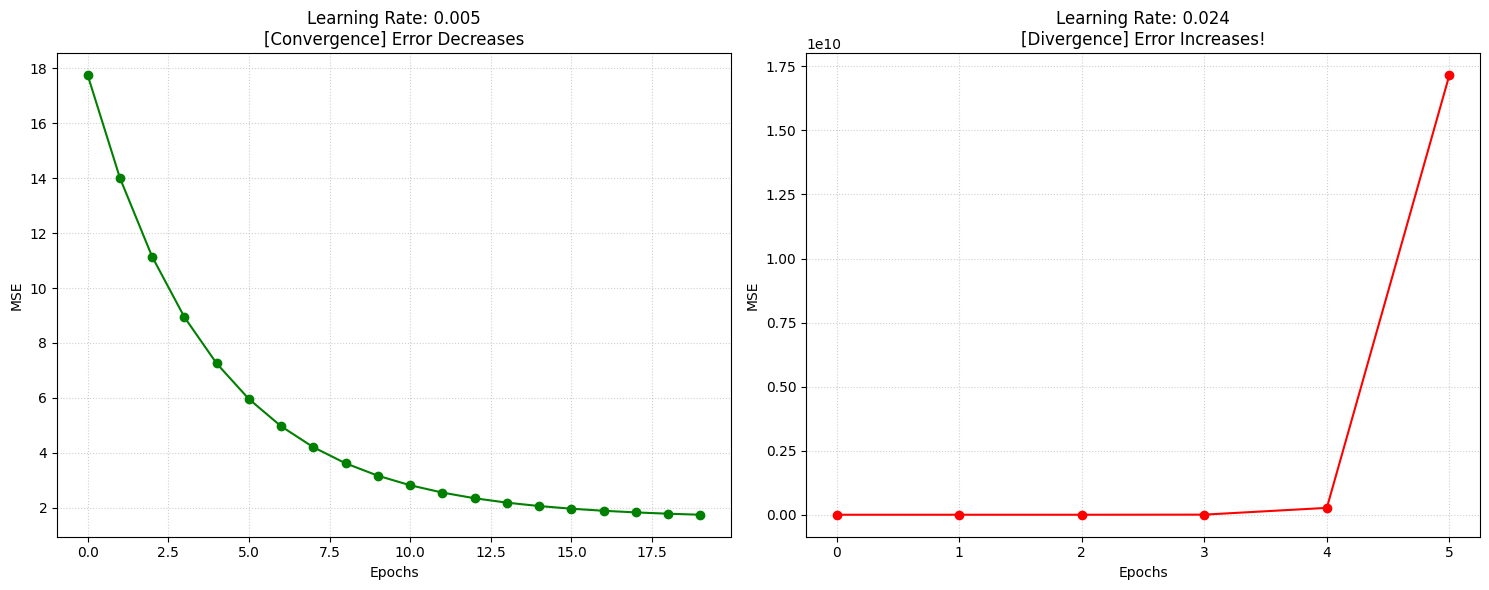

In [ ]:
#Ex2
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 준비
X = np.array([1, 4.5, 9, 10, 13])
y = np.array([0, 0.2, 2.5, 5.4, 7.3])

# 2. 비교할 학습률 설정 (적절한 값 vs 과도한 값)
learning_rates = [0.005, 0.024] # 0.024 근처에서 오차가 증폭되기 시작함
epochs = 20 # 변화를 뚜렷하게 보기 위해 짧은 구간 관찰

plt.figure(figsize=(15, 6))

# 학습률별 학습과정: 이중 반복문
for i, lr in enumerate(learning_rates):
    plt.subplot(1, 2, i + 1)

    w, b = 0.0, 0.0  # 초기화
    mse_history = []

    for epoch in range(epochs):
        y_pred = w * X + b
        error = y_pred - y
        mse = np.mean(error**2)
        mse_history.append(mse)

        # 파라미터 업데이트
        w = w - lr * (error * X).sum()
        b = b - lr * error.sum()

        # 오차가 너무 커지면(발산) 루프 중단 (그림 출력을 위해)
        if mse > 1e10: break

    # MSE 변화 그래프 출력
    plt.plot(range(len(mse_history)), mse_history, marker='o', color='red' if lr > 0.01 else 'green')
    plt.title(f'Learning Rate: {lr}\n' + ('[Divergence] Error Increases!' if lr > 0.01 else '[Convergence] Error Decreases'))
    plt.xlabel('Epochs')
    plt.ylabel('MSE')
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

--- 가중치(Weight) 및 편향(Bias) 비교 ---
GD Function: w = 1.6399, b = 6.8200
Sklearn:     w = 1.6399, b = 6.8200
회귀식: y = 1.64 * X + 6.82
데이터와 선형 회귀 직선의 관계점수(R2): 76.9%


/tmp/ipykernel_485/408132578.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Sklearn:     w = {sk_model.coef_.flatten()[0]:.4f}, b = {float(sk_model.intercept_):.4f}")
/tmp/ipykernel_485/408132578.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"회귀식: y = {sk_model.coef_.flatten()[0]:.2f} * X + {float(sk_model.intercept_):.2f}")


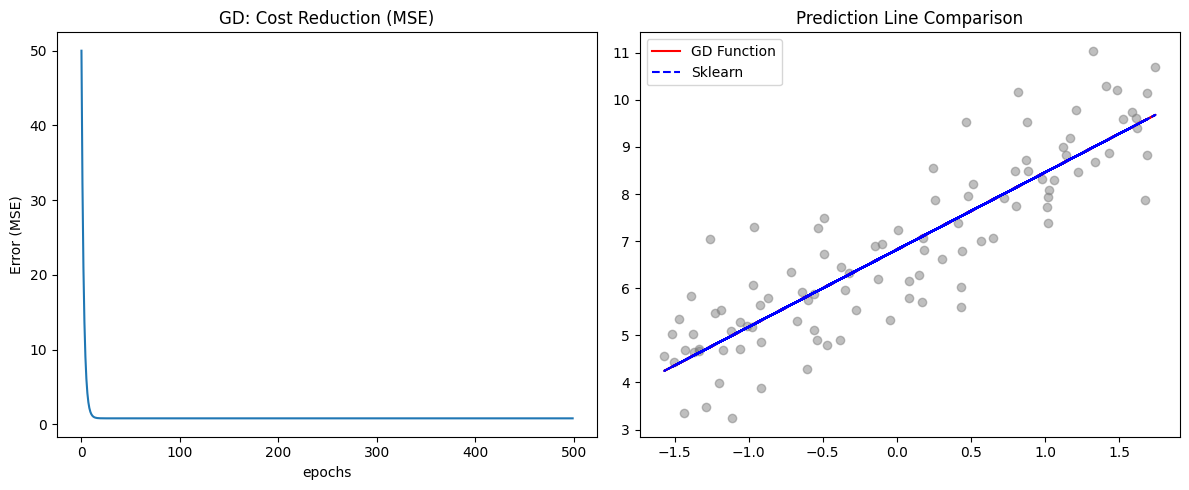

In [ ]:
# Ex3: 경사하강법을 이용한 선형회귀선  vs LinearRegression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# 1. 지도학습 데이터 생성 및 전처리
np.random.seed(42)
X = 2 * np.random.rand(100, 1) #(100,1) 2차원 배열
# X.shape[1]은 데이터가 가진 특징의 개수
y = 4 + 3 * X + np.random.randn(100, 1)

# GD 성능을 위해 스케일링 필수
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. 경사 하강법 함수 정의
def fit_gradient_descent(X, y, learning_rate=0.1, epoch=500):
    m = len(y)
    # [[0.]] 형태를 가진 (1, 1) 모양의 행렬

    W = np.zeros((X.shape[1], 1)) # 가중치 초기화 - 1행 1열의 2차원 행렬
    b = 0.0                       # 편향 초기화
    cost_history = []             # 비용 기록용 리스트

    for i in range(epoch):
        # 예측값 계산 (y_hat = WX + b)
        y_pred = np.dot(X, W) + b
        errors = y_pred - y

        # 그레디언트 계산 및 파라미터 업데이트
        w_gradient = (2/m) * np.dot(X.T, errors)
        b_gradient = (2/m) * np.sum(errors)

        W -= learning_rate * w_gradient
        b -= learning_rate * b_gradient

        # 비용 함수(MSE) 계산 및 기록
        cost = np.mean(errors**2)
        cost_history.append(cost)

    return W, b, cost_history

# 3. 모델 학습 진행
# (1) 직접 구현한 함수 호출
w_gd, b_gd, cost_history = fit_gradient_descent(X_scaled, y)

# (2) Scikit-learn 라이브러리 사용
sk_model = LinearRegression()
sk_model.fit(X_scaled, y)

# 4. 학습된 모델의 파라미터 확인 및 회귀선
print("--- 가중치(Weight) 및 편향(Bias) 비교 ---")
print(f"GD Function: w = {w_gd.flatten()[0]:.4f}, b = {b_gd:.4f}")
print(f"Sklearn:     w = {sk_model.coef_.flatten()[0]:.4f}, b = {float(sk_model.intercept_):.4f}")

print(f"회귀식: y = {sk_model.coef_.flatten()[0]:.2f} * X + {float(sk_model.intercept_):.2f}")

# 5.학습된 모델의 성능 평가 : 결정계수 (R-square)
hat_y = sk_model.predict(X_scaled) # 실제 데이터을 학습한 모델에 넣어 결과 추정하기
current_r2 = r2_score(y, hat_y) # 변수명을 함수명과 다르게 설정 (current_r2)
print(f"데이터와 선형 회귀 직선의 관계점수(R2): {current_r2:.1%}")


# 결과 출력 및 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cost_history)
plt.title('GD: Cost Reduction (MSE)')
plt.xlabel('epochs')
plt.ylabel('Error (MSE)')


plt.subplot(1, 2, 2)
plt.scatter(X_scaled, y, color='gray', alpha=0.5)
plt.plot(X_scaled, w_gd * X_scaled + b_gd, 'r-', label='GD Function')
plt.plot(X_scaled, sk_model.predict(X_scaled), 'b--', label='Sklearn')
plt.title('Prediction Line Comparison')
plt.legend()

plt.tight_layout()
plt.show()

# 3. 다중 선형 회귀 모델
- 단순 선형 회귀에서 **차원**이 확장

- [실습] 3개의 특성을 활용한 위험도 예측 다중 회귀 분석

  - 운동량, 식사량, 수면시간이라는 3가지 특성(Feature)을 사용해 **위험도**를 예측하는 다중 회귀 분석 모델을 구현
  - 변수가 3개이므로 3차원 공간을 넘어선 고차원 데이터가 된다.
  - 각 특성이 위험도에 주는 영향력을 개별적으로 확인하는 시각화 방법


[-13.9041156   15.08868937 -14.12607317]
52.156298086265636
--- 정규화 후 모델 학습 결과 ---
Exercise의 가중치(w): -13.9041
Meals의 가중치(w): 15.0887
Sleep의 가중치(w): -14.1261
절편(b): 52.16


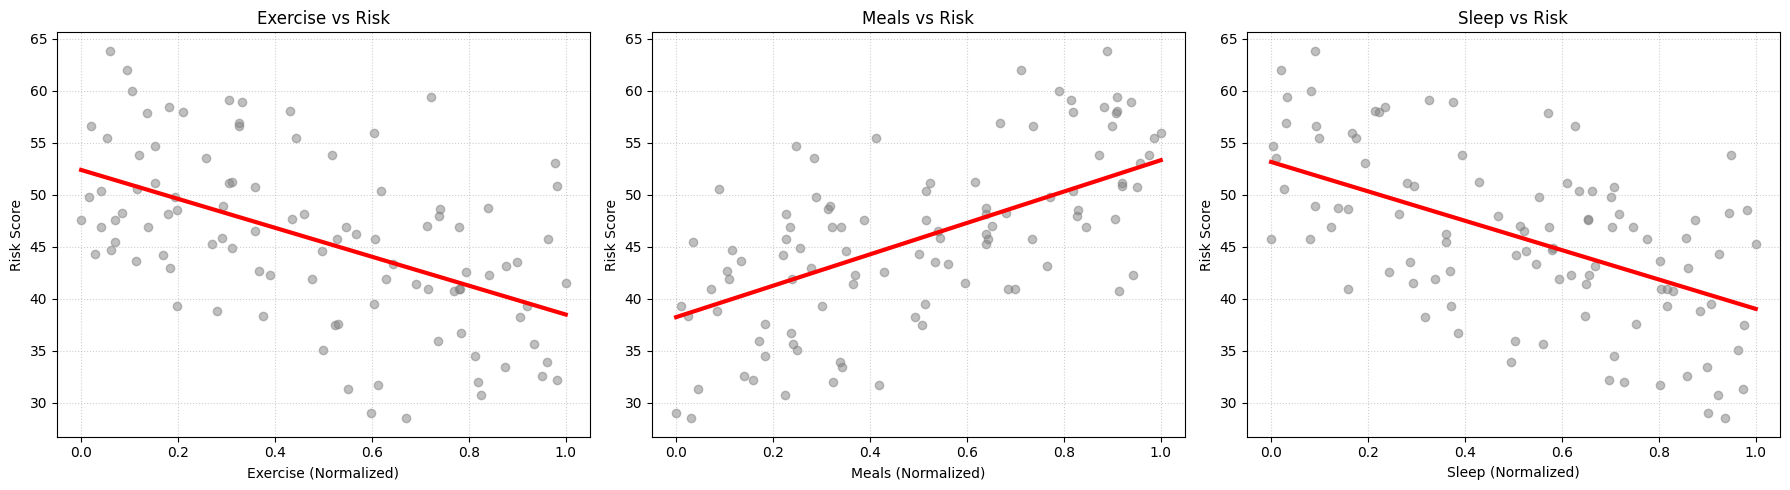

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

# 1. 지도학습 데이터 준비: (X, y)
np.random.seed(42)
n_samples = 100

exercise = np.random.uniform(0, 3, n_samples) # 시간 단위 : 0~3
meals = np.random.uniform(1500, 3000, n_samples) # 식사량 칼로리 단위 : 1500 ~ 3000
sleep = np.random.uniform(4, 9, n_samples) # 수면 시간단위 : 4~9

y_risk = (-5 * exercise) + (0.01 * meals) + (-3 * sleep) + 50 + np.random.normal(0, 2, n_samples)

# 정규화 함수 정의 (Min-Max Scaling)
def normalize(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

# 데이터 정규화 적용
exercise_n = normalize(exercise)
meals_n = normalize(meals)
sleep_n = normalize(sleep)

# 정규화된 feature 데이터를 학습입력 형식으로 통합: 2차원 배열
X_n = np.column_stack((exercise_n, meals_n, sleep_n))

# 2. 다중 회귀 모델 학습 (정규화된 데이터 사용): 가설 설정
regr = linear_model.LinearRegression()
regr.fit(X_n, y_risk) # 초평면을 예측
print(regr.coef_)
print(regr.intercept_)

# 3. 가중치(영향력) 확인
print("--- 정규화 후 모델 학습 결과 ---")
features = ['Exercise', 'Meals', 'Sleep']
for name, coef in zip(features, regr.coef_):
    # 이제 가중치의 절대값 크기로 어떤 요소가 위험도에 가장 큰 영향을 주는지 비교 가능.
    print(f"{name}의 가중치(w): {coef:.4f}")
print(f"절편(b): {regr.intercept_:.2f}")

# 4. 시각화: 각 특성별 위험도 관계
plt.figure(figsize=(18, 5))

for i, name in enumerate(features):
    plt.subplot(1, 3, i + 1)

    # 실제 데이터 산점도 (정규화된 X축)
    plt.scatter(X_n[:, i], y_risk, color='gray', alpha=0.5)

    # 추세선 계산
    line_x = np.linspace(X_n[:, i].min(), X_n[:, i].max(), 100)
    # 다른 특성들은 평균값으로 고정
    other_indices = np.delete([0, 1, 2], i)
    other_means = np.mean(X_n[:, other_indices], axis=0)
    other_contribution = np.sum(regr.coef_[other_indices] * other_means)

    line_y = regr.intercept_ + regr.coef_[i] * line_x + other_contribution

    plt.plot(line_x, line_y, color='red', linewidth=3)
    plt.xlabel(f'{name} (Normalized)')
    plt.ylabel('Risk Score')
    plt.title(f'{name} vs Risk')
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 4. 다항회귀모델

✅   최적화 vs 과대적합 vs 과소적합 vs 일반화
- 비선형 데이터 X
- 다항 회귀는 차수가 높아질수록 데이터 값($x, x^2, x^3...$)이 폭발적으로 증가
- StandardScaler를 Pipeline에 묶어 학습과 스케일링을 **한 번에 처리**
- Pipeline 구조:
  - Pipeline([ ('이름', 객체)]):
    -  각 단계마다 이름을 붙여주어야 함.
    -  나중에 이 이름을 통해 특정 단계의 파라미터에 접근
- Pipeline 활용:
  - 머신러닝 워크플로우는 데이터 전처리->모델 학습-> 예측의 과정을 거친다. Pipeline은 이 과정을 하나로 연결
    - 훈련(Train) 데이터와 테스트(Test) 데이터에 동일한 변환 순서를 강제
    - 여러 번의 fit과 transform 호출을 하나의 fit으로 줄여 코드가 훨씬 깔끔.
    - **하이퍼파라미터 튜닝**: GridSearchCV와 결합하여 전처리 단계와 모델의 파라미터를 한꺼번에 최적화
   

In [ ]:
# Ex: 다항회귀 구현
# 파이프라인을 통해 전처리와 다항 회귀를 한 번에 처리
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression







# 1. 비선형 데이터 생성(지도학습)
np.random.seed(42)
X = 2 - 3 * np.random.normal(0, 1, 100)
y = X - 2 * (X ** 2) + 0.5 * (X ** 3) + np.random.normal(-3, 3, 100)
X = X.reshape(-1, 1)

# 2. Pipeline 정의 (스케일링 -> 3차 다항식 변환 -> 선형 회귀)







# 3. 모델 학습





# 4. 시각화를 위한 예측 데이터 생성
# X의 최소값부터 최대값까지 범위를 만들어 곡선을 그리기.
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)





# 5. 결과 시각화
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='gray', alpha=0.5, label='Actual Data')
plt.plot(X_range, y_pred, color='red', linewidth=2, label='Pipeline Prediction (Degree 3)')
plt.title('Pipeline: Polynomial Regression Visualization', fontsize=14)
plt.xlabel('X (Input Feature)', fontsize=12)
plt.ylabel('y (Target)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

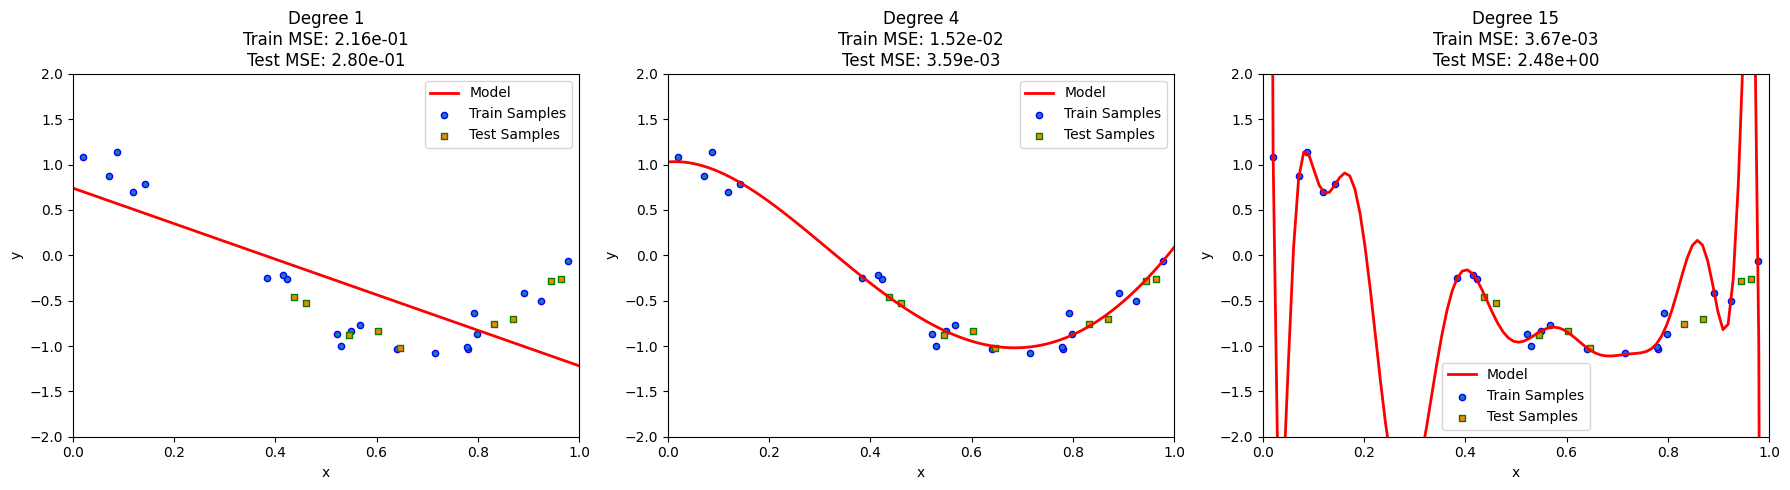

In [ ]:
# Ex:  8.9 - 8.10 다항 회귀의 과대적합(Overfitting) 테스트 및 시각화
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error







# 1. 지도학습 데이터 생성 (노이즈가 포함된 코사인 곡선 형태)
np.random.seed(0)
n_samples = 30
X = np.random.rand(n_samples) # 0 이상 1 미만의 구간에서 균등 분포를 따르는 난수를 생성
y = np.cos(1.5 * np.pi * X) + np.random.randn(n_samples) * 0.1
X = X.reshape(-1,1)

# 데이터 분할 (학습용 vs 테스트용)




# 2. 여러 차수(Degrees)에 따른 모델 비교
degrees = [1, 4, 15] # 1: 과소적합, 4: 적정, 15: 과대적합

plt.figure(figsize=(18, 5))

for i, degree in enumerate(degrees):
    ax = plt.subplot(1, len(degrees), i + 1)

    # 파이프라인 구축: 데이터표준화->다항 변환 -> 선형 회귀 학습








    # 모델 학습




    # 평가 지표 계산





    # 시각화 준비
    X_plot = np.linspace(0, 1, 100).reshape(-1,1)
    plt.plot(X_plot, pipeline.predict(X_plot), label="Model", color='red', linewidth=2)
    plt.scatter(X_train, y_train, edgecolor='b', s=20, label="Train Samples")
    plt.scatter(X_test, y_test, edgecolor='g', s=20, label="Test Samples", marker='s')

    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title(f"Degree {degree}\nTrain MSE: {train_mse:.2e}\nTest MSE: {test_mse:.2e}")

plt.tight_layout()
plt.show()

✅다항 회귀 복잡도 분석
- 다항 회귀의 차수를 1차부터 10차까지 변화시키면서 Train Error와 Test Error의 변화를 추적하여 최적의 복잡도를 찾기

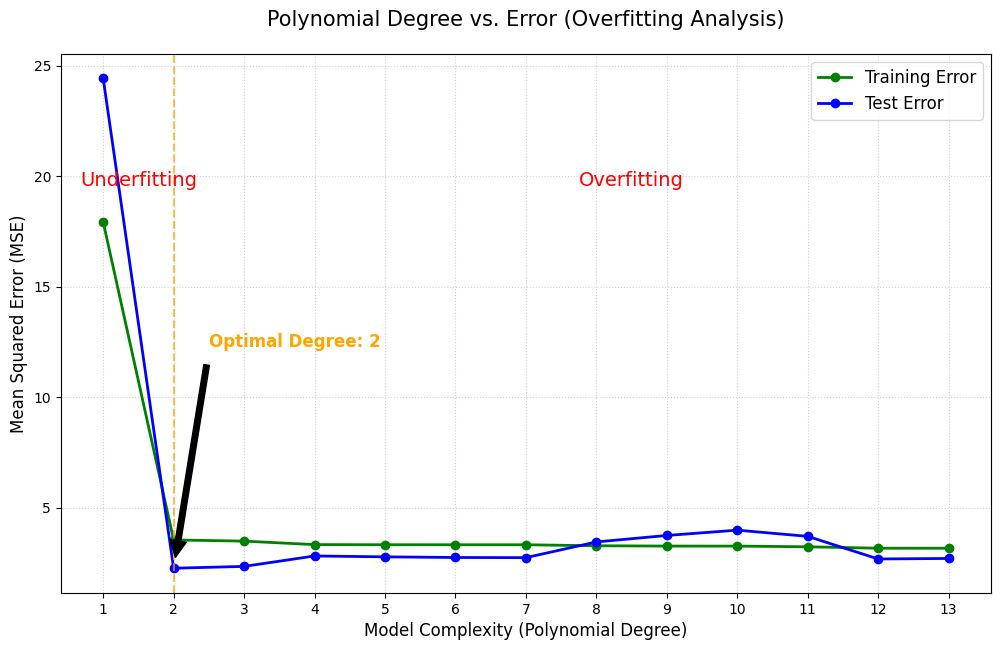

최적의 다항식 차수: 2차


In [ ]:
# Ex: 다항회귀 모델의 복잡도 vs 과대적합 관계
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
# 1. 비선형 데이터 생성
np.random.seed(42)
n_samples = 100
X = np.random.rand(n_samples, 1) * 10
# 비선형 관계: y = 0.5 * x^2 - 5 * x + 노이즈
y = 0.5 * (X**2).flatten() - 5 * X.flatten() + 2 + np.random.randn(n_samples) * 2

# 데이터 분할 (Train / Test)



# 2. 모델 복잡도에 따른 에러 추적
degrees = np.arange(1, 14)  # 1차항부터 13차항까지
train_errors = []
test_errors = []












# 3. 최적의 차수 찾기 (Test Error가 가장 낮은 지점)






# 4. 시각화 구현
plt.figure(figsize=(12, 7))

# 에러 곡선 그리기
plt.plot(degrees, train_errors, "g-o", linewidth=2, label="Training Error")
plt.plot(degrees, test_errors, "b-o", linewidth=2, label="Test Error")

# 최적 지점 표시
plt.axvline(x=optimal_degree, color='orange', linestyle='--', alpha=0.7)
plt.annotate(f'Optimal Degree: {optimal_degree}',
             xy=(optimal_degree, test_errors[optimal_degree-1]),
             xytext=(optimal_degree+0.5, test_errors[optimal_degree-1]+10),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, color='orange', fontweight='bold')

# 그래프 상세 설정
plt.title("Polynomial Degree vs. Error (Overfitting Analysis)", fontsize=1)
plt.xlabel("Model Complexity (Polynomial Degree)", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.xticks(degrees)
plt.grid(True, linestyle=':', alpha=0.6)
plt.text(1.5, max(test_errors)*0.8, "Underfitting", fontsize=14, color="red", ha="center")
plt.text(8.5, max(test_errors)*0.8, "Overfitting", fontsize=14, color="red", ha="center")
plt.legend(loc="upper right", fontsize=12)
plt.show()

print(f"최적의 다항식 차수: {optimal_degree}차")

# 5. 규제 회귀 모델 (Ridge  Regression)

- 1. Alpha는 어떻게 결정되나요?
  - 너무 작은 Alpha (예: 0.0001):
    - 규제가 거의 없어 모델이 훈련 데이터의 노이즈까지 다 외워버림
    - **과대적합(Overfitting)이 발생하여 테스트 점수가 낮게 나옴**.

  - 너무 큰 Alpha (예: 100.0):
    - 규제가 너무 강해 모델의 학습 의지를 꺾어버림.
    - 데이터의 패턴을 무시하는 **과소적합**(Underfitting)이 발생하여
    - **훈련/테스트 점수가 모두 낮아짐**.

  - 적절한 Alpha :
    - 훈련 데이터에 너무 집착하지 않으면서도
    - 핵심 패턴은 잘 잡아내어,
    - **테스트 점수가 가장 높게 유지되는 지점**.

- 2. 최적의 Alpha를 찾는 시각적 도구
  - **로그 스케일로 alpha 값을 바꿔가며 점수를 기록한 그래프**
  - 그래프 해석: 왼쪽에서 오른쪽으로 갈수록 규제가 강해짐.
  - 최적점(Best Alpha):
    - **테스트 스코어(Test Score) 곡선의 꼭대기 지점**

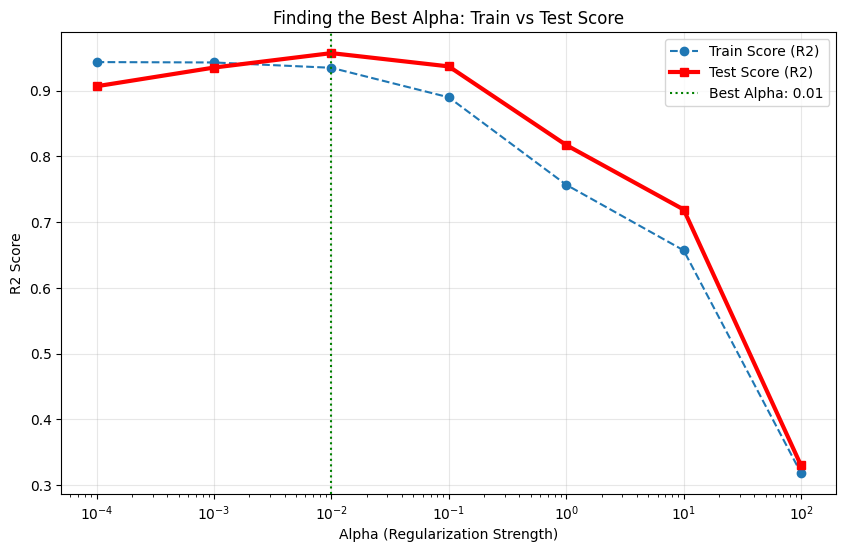

In [ ]:
# EX: 규제 Ridge 회귀 모델 이해
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

# 1. 데이터 생성 (노이즈가 포함된 사인 곡선)
np.random.seed(42)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = np.sin(2 * np.pi * X) + np.random.randn(n_samples) * 0.2
X = X.reshape(-1,1)

# 데이터 분할 (Train/Test)





# 2. 다양한 Alpha 값에 따른 점수 기록
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
train_scores = []
test_scores = []













# 3. 결과 시각화
plt.figure(figsize=(10, 6))
plt.plot(alphas, train_scores, label="Train Score (R2)", marker='o', linestyle='--')
plt.plot(alphas, test_scores, label="Test Score (R2)", marker='s', linewidth=3, color='red')

# X축을 로그 스케일로 설정 (Alpha 값의 변화를 보기 편하게)




plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R2 Score')
plt.title('Finding the Best Alpha: Train vs Test Score')

# 최적의 지점 표시 (Test Score가 최대인 곳)




plt.axvline(best_alpha, color='green', linestyle=':', label=f'Best Alpha: {best_alpha}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

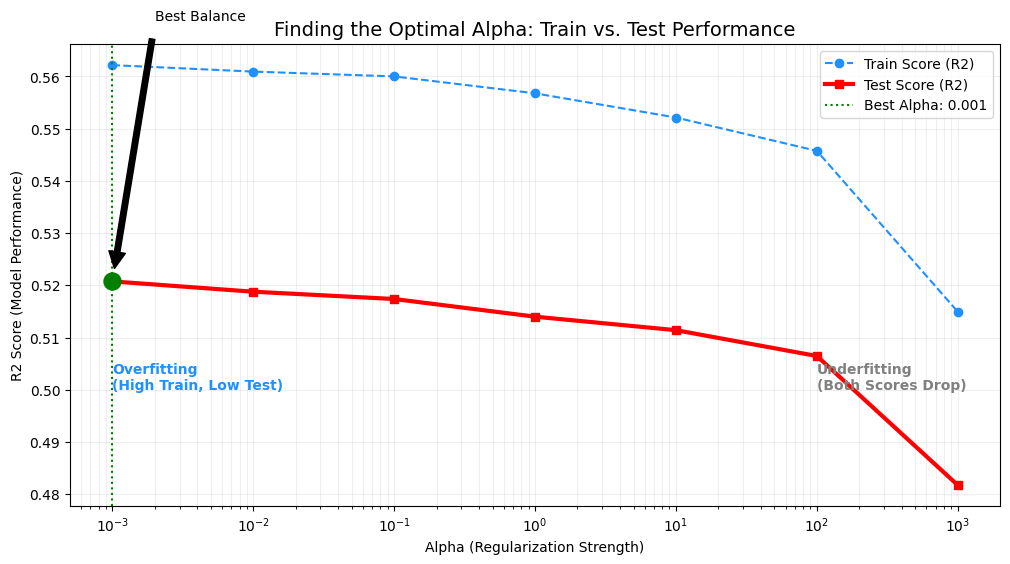

최적의 규제 강도(Alpha): 0.001
그때의 테스트 점수(R2): 0.5207


In [ ]:
# Ex : kaggle dataset with Ridge
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline





# 1. 데이터 로드 및 분할 (기대수명 데이터)
url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df = pd.read_csv(url).dropna()
X = df[['Schooling']].values
y = df['Life expectancy'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 분석할 alpha 값들의 범위 설정 (로그 스케일)
# 규제가 아주 약한 0.001부터 아주 강한 1000까지 테스트.
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_scores = []
test_scores = []



















# 3. 최적의 Alpha 지점 찾기 (Test Score가 최대인 지점)










# 4. 성능 변화 시각화
plt.figure(figsize=(12, 6))

# 훈련 점수와 테스트 점수 그리기
plt.plot(alphas, train_scores, label='Train Score (R2)', marker='o', linestyle='--', color='dodgerblue')
plt.plot(alphas, test_scores, label='Test Score (R2)', marker='s', linewidth=3, color='red')

# 최적의 지점 표시
plt.axvline(best_alpha, color='green', linestyle=':', label=f'Best Alpha: {best_alpha}')
plt.scatter(best_alpha, test_scores[best_idx], color='green', s=150, zorder=5)

plt.xscale('log') # alpha 값의 차이가 크므로 로그 스케일 적용
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R2 Score (Model Performance)')
plt.title('Finding the Optimal Alpha: Train vs. Test Performance', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()

plt.text(0.001, 0.5, 'Overfitting\n(High Train, Low Test)', color='dodgerblue', fontweight='bold')
plt.text(100, 0.5, 'Underfitting\n(Both Scores Drop)', color='gray', fontweight='bold')
plt.annotate('Best Balance', xy=(best_alpha, test_scores[best_idx]), xytext=(best_alpha*2, test_scores[best_idx]+0.05),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

print(f"최적의 규제 강도(Alpha): {best_alpha}")
print(f"그때의 테스트 점수(R2): {test_scores[best_idx]:.4f}")

<>:57: SyntaxWarning: invalid escape sequence '\l'
<>:57: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_14266/1689507184.py:57: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("Model Complexity (Low $\leftrightarrow$ High)")


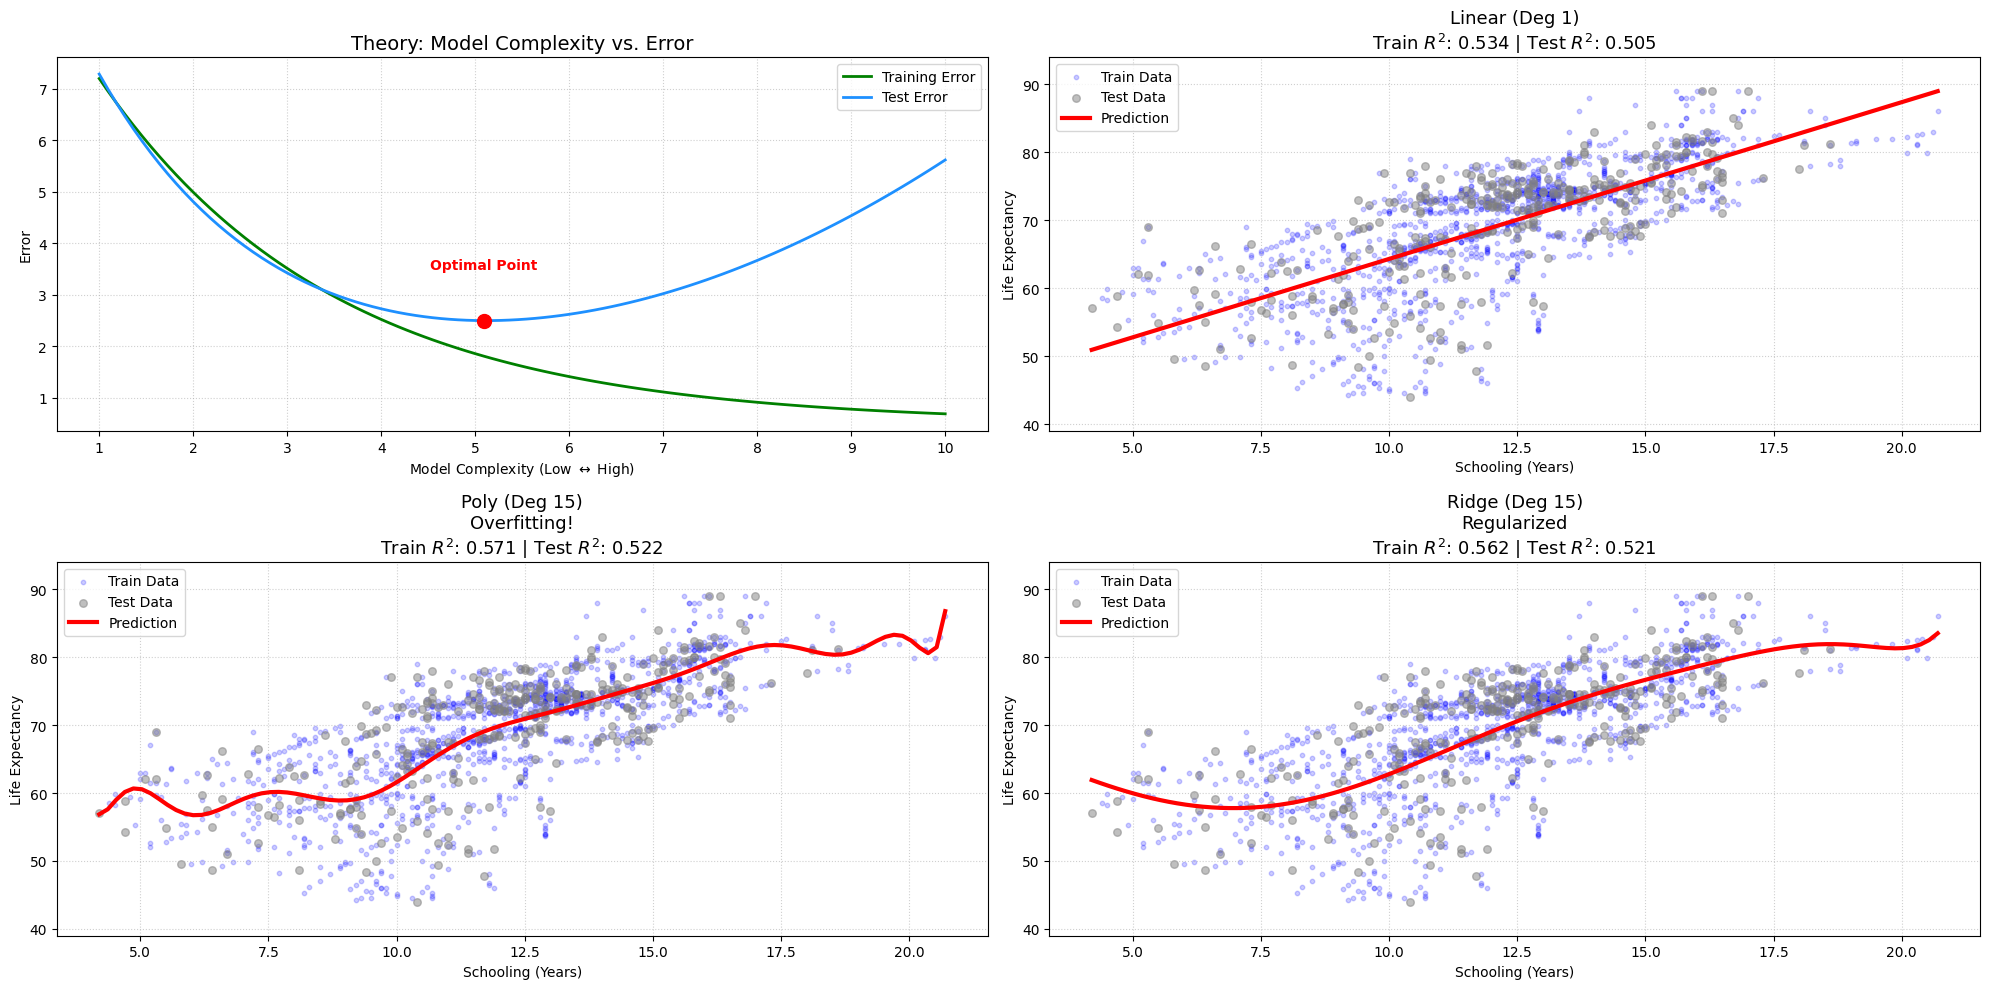

In [ ]:
# Ex: 모델 복잡도, 과대적합, 그리고 릿지 규제의 통합 분석-  kaggle dataset
# 다양한  회귀모델 성능 비교
# 기대수명과 교육수준과의 상관관계

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

# 1. 지도학습 데이터 준비 (기대수명과 교육수준)
url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df = pd.read_csv(url).dropna()

X = df[['Schooling']].values  # 특성 (2차원)
y = df['Life expectancy'].values  # 타겟 (1차원)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 이론적 배경: 모델 복잡도 vs 오차 관계 데이터 생성
complexity = np.linspace(1, 10, 100)
train_error_theory = 10 * np.exp(-0.4 * complexity) + 0.5
test_error_theory = 8 * np.exp(-0.6 * complexity) + 0.1 * (complexity - 4)**2 + 2
optimal_idx = np.argmin(test_error_theory)

# 3. 비교 모델 설정 (Pipeline 활용)
# Degree 15를 사용하여 의도적으로 과대적합을 유도하고, Ridge로 이를 해결.

















# 4. 전체 시각화 (이론 그래프 1개 + 모델 비교 3개 = 총 4개 영역)
plt.figure(figsize=(20, 10))

# --- (A) 이론 영역: 복잡도 vs 오차 ---
plt.subplot(2, 2, 1)
plt.plot(complexity, train_error_theory, label='Training Error', color='green', lw=2)
plt.plot(complexity, test_error_theory, label='Test Error', color='dodgerblue', lw=2)
plt.scatter(complexity[optimal_idx], test_error_theory[optimal_idx], color='red', s=100)
plt.title("Theory: Model Complexity vs. Error", fontsize=14)
plt.xlabel("Model Complexity (Low $\leftrightarrow$ High)")
plt.ylabel("Error")
plt.xticks(np.arange(1, 11, 1))
plt.text(complexity[optimal_idx], test_error_theory[optimal_idx]+1, 'Optimal Point', ha='center', color='red', fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# --- (B) 실제 영역: 모델별 성능 비교 ---
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

for i, (name, model) in enumerate(models):
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    plt.subplot(2, 2, i+2)
    plt.scatter(X_train, y_train, color='blue', s=10, alpha=0.2, label='Train Data')
    plt.scatter(X_test, y_test, color='gray', s=30, alpha=0.5, label='Test Data')
    plt.plot(X_range, model.predict(X_range), color='red', linewidth=3, label='Prediction')

    plt.title(f"{name}\nTrain $R^2$: {train_score:.3f} | Test $R^2$: {test_score:.3f}", fontsize=13)
    plt.xlabel('Schooling (Years)')
    plt.ylabel('Life Expectancy')
    plt.ylim(y.min()-5, y.max()+5)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# # 웹서비스 배포

✅ Streamlit으로 배포
- 터미널(또는 CMD)에서 pip install streamlit 라이브러리를 먼저 설치 후,
- **streamlit run 파일명.py**를 입력.

✅ 코랩에서 Streamlit 웹 배포 실행 절차
- 1단계: 필수 라이브러리 설치
  - 코랩 셀에 아래 명령어를 입력하여 Streamlit과 외부 접속용 도구를 설치.
    - !pip install streamlit -q
    - !pip install pyngrok -q
- 2단계: Streamlit 앱 코드 저장하기
  - 코랩의 파일 시스템에 app.py라는 이름으로 실행할 파이썬 코드를 저장.
- 3단계: 외부 접속 주소 생성 및 서버 실행
  - 코랩의 가상 서버는 외부에서 접속이 차단되어 있으므로, 공인 IP를 확인하고 터널링을 통해 임시 웹 주소를 만든다.
    - "터널링(Tunneling)" 개념 :
      - "코랩이라는 닫힌 방에 외부 사람이 들어올 수 있도록 임시 비밀 통로"     
        - 172.28.0.12는 코랩 내부 망 주소이며,
        - 34.182.190.203은 코랩 서버의 공인 IP
        - 브라우저는 보안상의 이유로 이 주소들에 직접 접근하는 것을 차단.
             
  - ngrok으로 대체하기 (더 안정적인 방법)
    - ngrok 홈페이지에 접속해서 무료 가입 후 Authtoken을 복사.
      - ngrok 대시보드 사이트에 접속
        - https://dashboard.ngrok.com/login
      - Google계정으로 가입(Sign up) 및 로그인
      - 왼쪽 메뉴에서 "Your Authtoken"을 클릭하면, 영문과 숫자가 섞인 긴 암호(토큰)을 복사
      - 코드 실행 후 하단에 생성된 https://....ngrok-free.app 형태의 파란색 링크를 클릭하면 대시보드가 열림
    - 로딩 에러(Connection Timed Out) 문제 발생시 해결:
      - 코랩에서 실행 중인 셀을 중지하고 코드를 다시 실행.


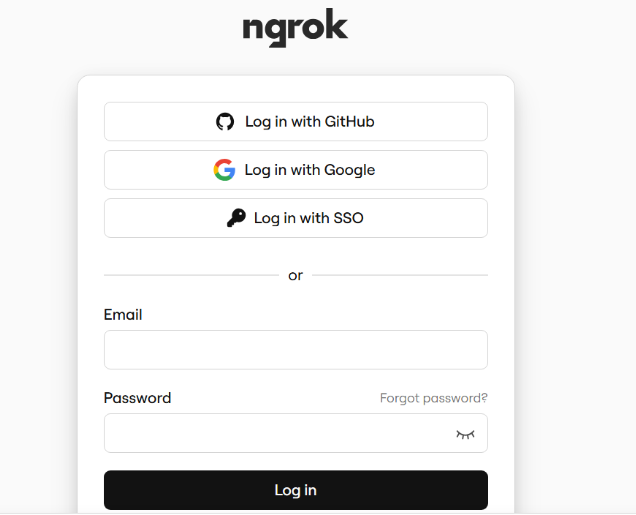

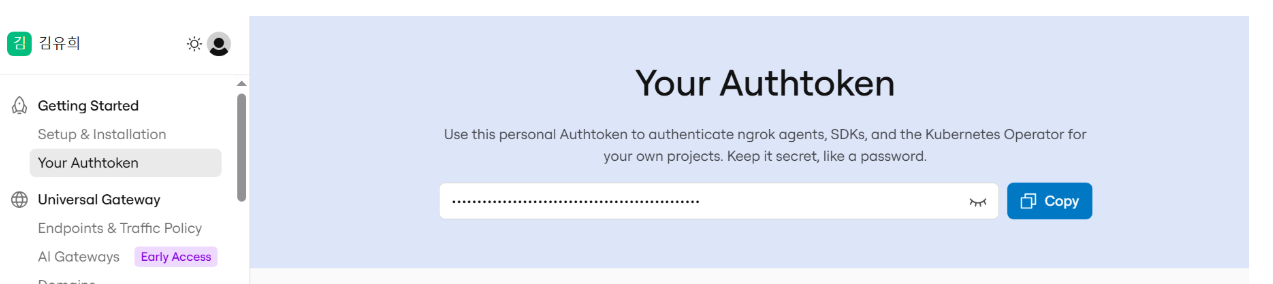

✅ ngrok을 활용한 건강 위험도 분석을 구글 코랩에서 웹 서비스로 배포하기
- 1단계: ngrok Authtoken 준비하기
- 2단계: 코랩에서 필수 라이브러리 설치
  - 다중회귀분석 로직 작성
    - 예측모델 저장의 이유 :
      - 학습 데이터가 수백만 개라면 학습에만 몇 시간이 걸림
      - .pkl 파일은 용량이 매우 작고, 불러오자마자 즉시 예측할 수 있음
    - 데이터 기준값(stats)의 중요성:
      - 예측할 때도 학습할 때와 동일한 기준으로 정규화를 해야 함
      - 모델뿐만아니라 학습 당시의 Min, Max 값도 함께 저장해서 웹 앱으로 넘겨 줌

In [ ]:
# Streamlit과 ngrok 설치
!pip install streamlit -q
!pip install pyngrok -q

In [ ]:
# 다중회귀분석 로직 작성
import numpy as np
from sklearn import linear_model
import joblib  # 모델 저장 및 로드 라이브러리

# 1. 데이터 생성 (학습 과정)
np.random.seed(42)
n_samples = 100
exercise = np.random.uniform(0, 3, n_samples)
meals = np.random.uniform(1500, 3000, n_samples)
sleep = np.random.uniform(4, 9, n_samples)
y_risk = (-5 * exercise) + (0.01 * meals) + (-3 * sleep) + 50 + np.random.normal(0, 2, n_samples)

# 정규화 기준값 저장 (예측 시 동일하게 적용해야 함)





# 데이터 정규화
def normalize(data, d_min, d_max):
    return (data - d_min) / (d_max - d_min)

X_n = np.column_stack((
    normalize(exercise, stats['ex_min'], stats['ex_max']),
    normalize(meals, stats['ml_min'], stats['ml_max']),
    normalize(sleep, stats['sl_min'], stats['sl_max'])
))


# 2. 모델 학습
regr = linear_model.LinearRegression()
regr.fit(X_n, y_risk)

# 3. 모델과 기준값을 파일로 저장 (.pkl 확장자)





print("✅ 모델과 기준값이 파일로 저장되었습니다: health_model.pkl, data_stats.pkl")

- 3단계: 저장된 모델을 사용하는 웹 앱 코드(app.py) 작성
  - app.py는 데이터를 새로 만들거나 학습하지 않고, 오직 저장된 파일만 읽어서 작동.
    - 다중 회귀 분석 로직을 웹 화면용으로 구성하여 파일로 저장
    
  - 예측 전용 서비스:
    - app.py 코드을 보면 regr.fit()함수가 없음
    - 이미 공부를 마친 인공지능 파일(model)이 있으므로
    - model.predict()만 수행하면 됨


In [ ]:
%%writefile app.py

import streamlit as st
import numpy as np
import joblib
import matplotlib.pyplot as plt

# 1. 저장된 모델 및 기준값 불러오기





st.set_page_config(page_title="건강 위험도 분석", layout="wide")
st.title("🏥 AI 건강 위험도 예측 및 분석 서비스")

# 2. 사용자 입력 UI (사이드바)
st.sidebar.header("📋 나의 정보 입력")
u_ex = st.sidebar.slider("운동 시간 (0~3시간)", 0.0, 3.0, 1.5)
u_ml = st.sidebar.slider("식사량 (1500~3000kcal)", 1500, 3000, 2250)
u_sl = st.sidebar.slider("수면 시간 (4~9시간)", 4.0, 9.0, 7.0)

# 3. 입력 데이터 정규화





# 4. 예측 수행





# 결과 출력
st.subheader("🎯 당신의 진단 결과")
st.metric("예상 건강 위험도 점수", f"{prediction[0]:.2f} 점")

# 5. 요인별 분석 그래프 (시각화 추가)
st.divider()
st.subheader("📈 인공지능이 분석한 요인별 영향도")
st.write("빨간 선의 기울기가 가파를수록 해당 요인이 위험도에 큰 영향을 미칩니다.")

features = ['Exercise', 'Meals', 'Sleep']
cols = st.columns(3)

# 모델에서 학습된 가중치(w)와 절편(b) 꺼내기
weights = model.coef_
intercept = model.intercept_

for i, name in enumerate(features):
    with cols[i]:
        fig, ax = plt.subplots(figsize=(5, 4))

        # 가상의 정규화된 X축 생성 (0~1)
        line_x = np.linspace(0, 1, 100)

        # 다른 두 특성은 현재 사용자의 입력값(정규화된 값)으로 고정
        user_inputs_n = [u_ex_n, u_ml_n, u_sl_n]
        other_indices = np.delete([0, 1, 2], i)

        # 다른 특성들의 기여도 계산
        other_contribution = sum(weights[idx] * user_inputs_n[idx] for idx in other_indices)

        # 추세선 y = w*x + (다른 요인들의 기여도 + 절편)
        line_y = weights[i] * line_x + other_contribution + intercept

        ax.plot(line_x, line_y, color='red', linewidth=3, label='Trend')

        # 현재 사용자의 위치 표시
        ax.scatter(user_inputs_n[i], prediction[0], color='blue', s=100, zorder=5, label='You')

        ax.set_xlabel(f'{name} (Normalized)')
        ax.set_ylabel('Risk Score')
        ax.set_title(f'{name} Factor Analysis')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend()

        st.pyplot(fig)

# 요인별 영향력 수치 표시
st.info(f"💡 분석 결과: 위험도에 가장 큰 영향을 주는 요인은 **{features[np.argmax(np.abs(weights))]}**입니다.")
# 가중치 분석 (모델 속성 확인)
st.divider()
st.subheader("💡 인공지능이 판단한 주요 요인 (가중치)")
for name, coef in zip(features, model.coef_):
    st.write(f"**{name}**의 영향력: {coef:.2f}")

- 4단계: ngrok 서버 실행 및 접속
  - 복사한 토큰을 사용하여 터널을 열고 웹 주소를 생성.
  - 생성된 ngrok-free.app 링크는 전 세계 어디서든 접속 가능한 실제 웹 주소임
   
  ✅ 최종 체크리스트
    - 코랩 왼쪽 파일 목록에 app.py, health_model.pkl, data_stats.pkl 파일 3개가 다 있는지 확인
    - ngrok-free.app 링크를 클릭.
      - 인공지능 건강 관리 대시보드가 열릴 것!
      - 슬라이더: 슬라이더를 움직일 때마다 위험도 점수가 실시간으로 변하는 과정을 통해 머신러닝의 예측 개념을 이해.
   

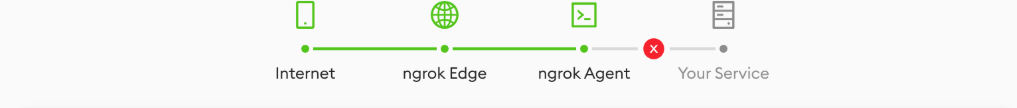

In [ ]:
# 기존 코드를 멈추고, 아래 코드로 다시 실행.
!pip install streamlit pyngrok -q
from pyngrok import ngrok
import os

# 1. 혹시 열려있을지 모르는 기존 터널 모두 닫기
ngrok.kill()

# 2. 인증 토큰 설정 (여기에 본인의 토큰을 붙이기)
ngrok.set_auth_token("토큰")

# 3. Streamlit 실행 (서버 주소를 명시적으로 127.0.0.1로 고정)
os.system("streamlit run app.py --server.address 127.0.0.1 &")

# 4. ngrok 터널 연결
public_url = ngrok.connect(8501, bind_tls=True) #(8501 포트의 127.0.0.1 주소를 바라보게 함)
print(f"아래 링크를 클릭하세요:\n{public_url}")


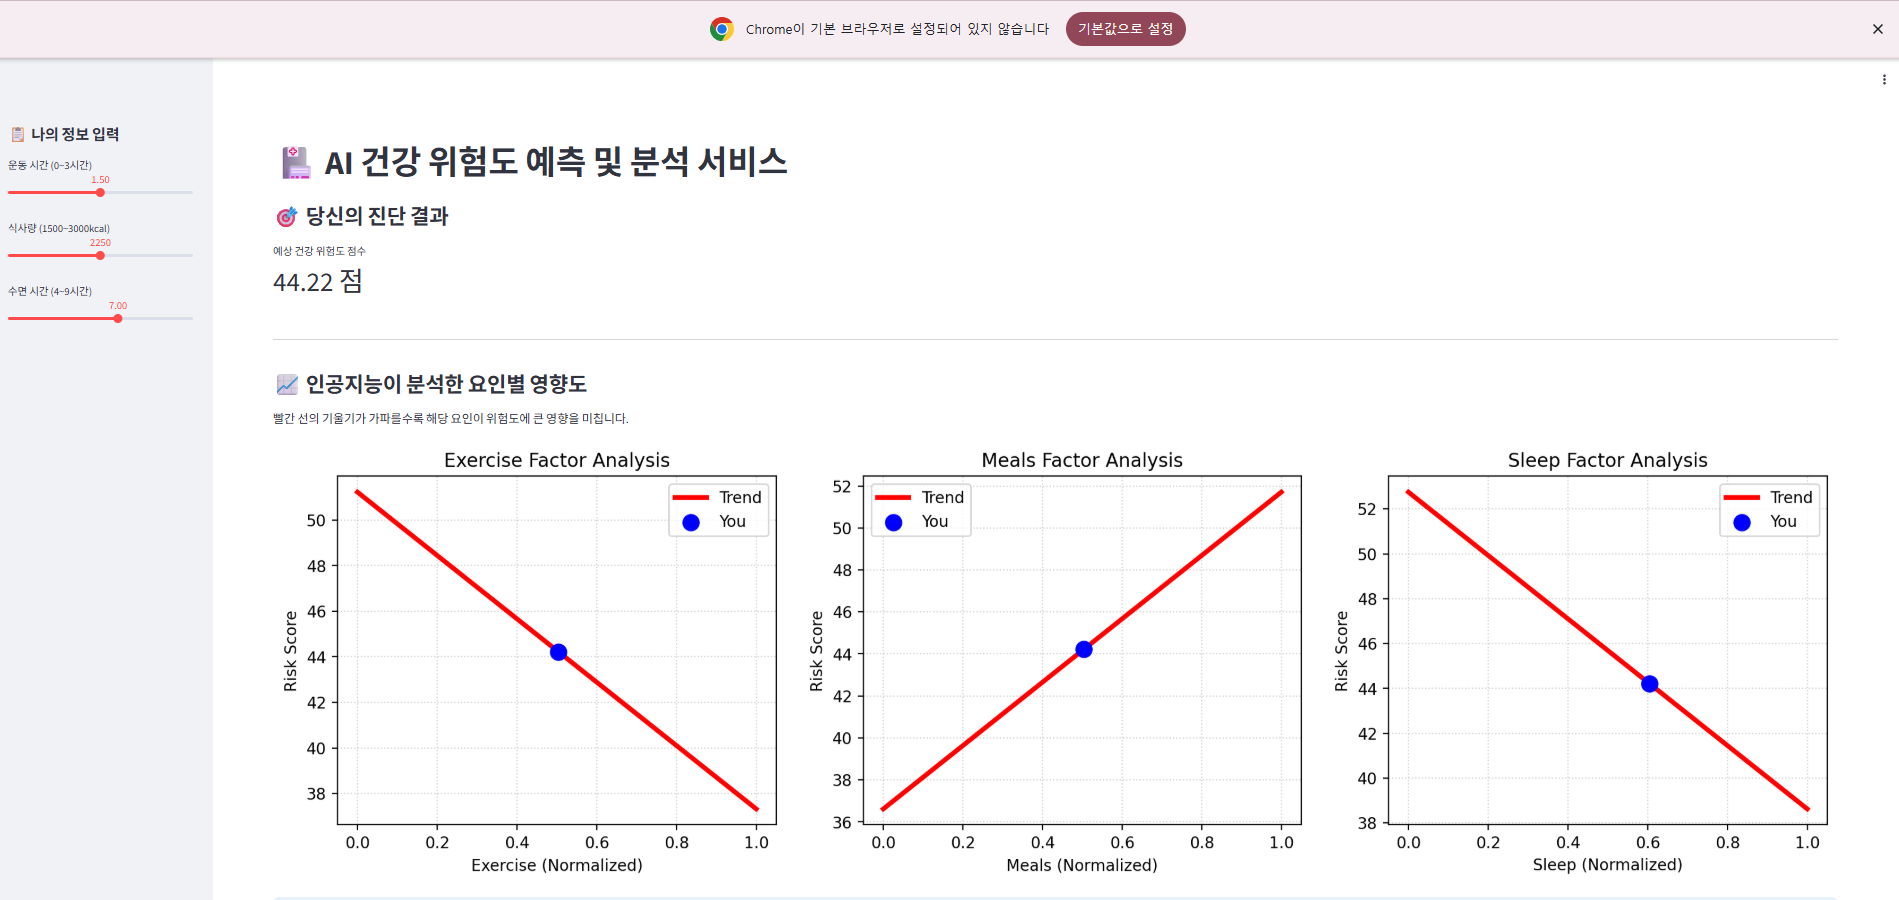

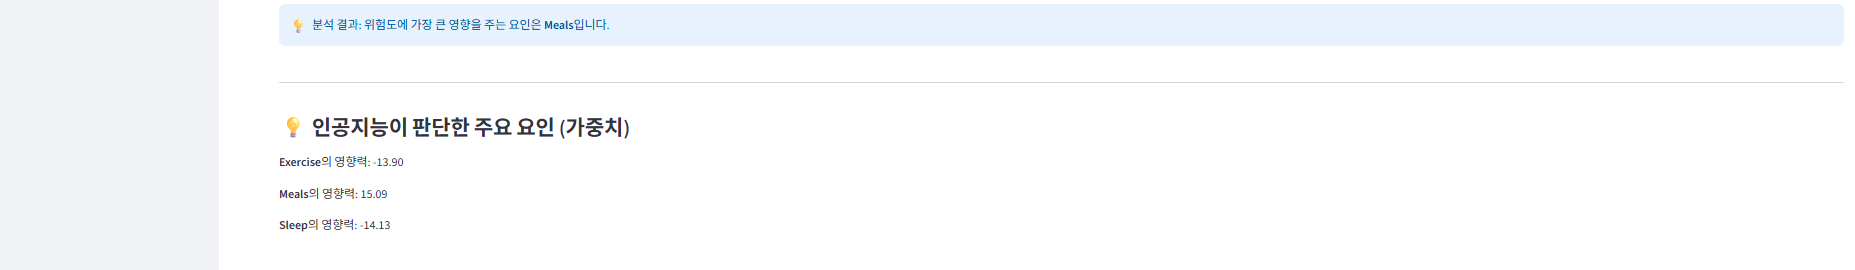